In [15]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [16]:
x = np.random.randint(-40, 40, size=(1000, 2))
y = np.array([i[0]*3 + i[1]*4 for i in x])

# criar sequência
timesteps = 5

X_seq = []
y_seq = []

for i in range(len(x) - timesteps):
    X_seq.append(x[i:i+timesteps])
    y_seq.append(y[i+timesteps])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq).reshape(-1,1)

# split
x_train, x_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [17]:
model = Sequential([
    
    LSTM(1, input_shape=(5, 2)),
    Dense(1, activation='linear'),
])

# Compilação
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Resumo
model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 1)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18 (72.00 B)

 Trainable params: 18 (72.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Treinamento
model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 12646.0322 - mae: 91.5781 - val_loss: 11960.2812 - val_mae: 90.1489
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12645.8779 - mae: 91.5777 - val_loss: 11960.3574 - val_mae: 90.1497
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12645.7725 - mae: 91.5776 - val_loss: 11960.4619 - val_mae: 90.1507
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12645.6543 - mae: 91.5774 - val_loss: 11960.5508 - val_mae: 90.1518
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12645.5049 - mae: 91.5770 - val_loss: 11960.6084 - val_mae: 90.1525
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12645.3936 - mae: 91.5768 - val_loss: 11960.7158 - val_mae: 90.1539
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 12645.1924 - mae: 91.5762 - val_loss: 11960.8154 - val_mae: 90.1549
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12645.0176 - mae: 91.5756 - val_loss: 11960.9072 - 

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


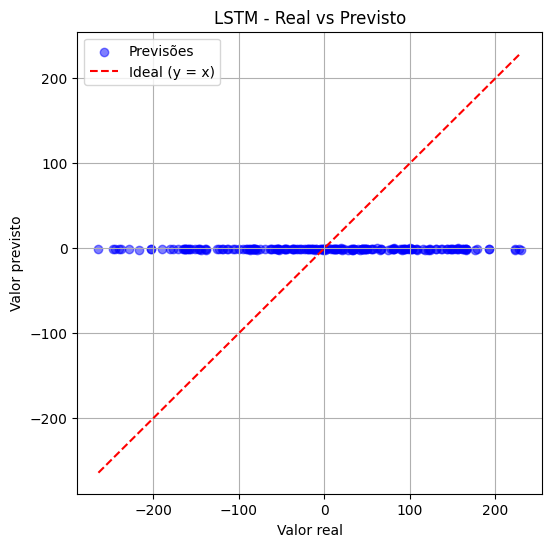

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# previsão
y_pred = model.predict(x_test)

# achatar arrays (IMPORTANTE)
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

plt.figure(figsize=(6,6))

plt.scatter(y_test_flat, y_pred_flat, color='blue', alpha=0.5, label='Previsões')

# linha ideal y = x
min_v = min(y_test_flat.min(), y_pred_flat.min())
max_v = max(y_test_flat.max(), y_pred_flat.max())

plt.plot([min_v, max_v], [min_v, max_v],
         color='red', linestyle='--', label='Ideal (y = x)')

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("LSTM - Real vs Previsto")
plt.legend()
plt.grid()

plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


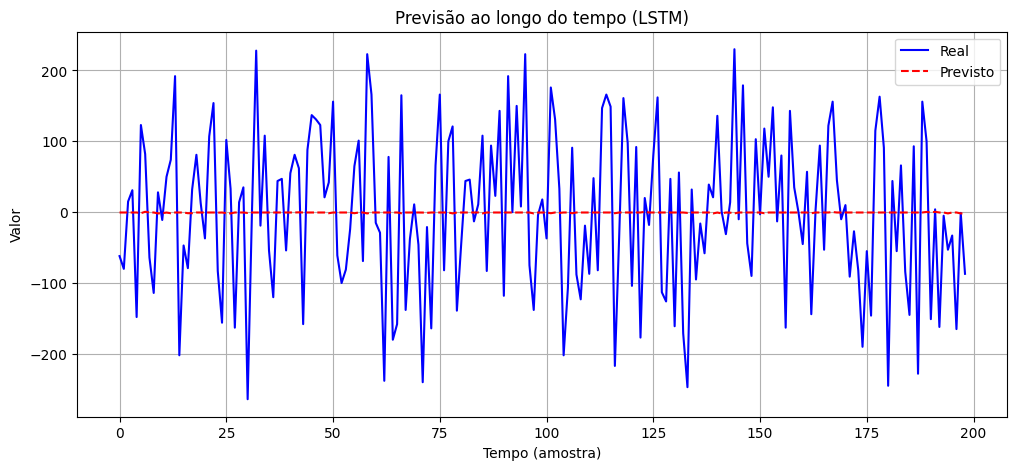

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# previsões
y_pred = model.predict(x_test)

# achatar
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred.reshape(-1)

# eixo do tempo (índice das amostras)
t = np.arange(len(y_test_flat))

plt.figure(figsize=(12,5))

plt.plot(t, y_test_flat, label="Real", color="blue")
plt.plot(t, y_pred_flat, label="Previsto", color="red", linestyle="--")

plt.xlabel("Tempo (amostra)")
plt.ylabel("Valor")
plt.title("Previsão ao longo do tempo (LSTM)")
plt.legend()
plt.grid()

plt.show()

In [21]:
import numpy as np

x = np.array([[1, 0.5]] * 5)      # (5, 2)
x = x.reshape(1, 5, 2)            # (1, 5, 2)

y_pred = model.predict(x)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
[[-0.14970493]]


In [22]:
import numpy as np

weights = model.weights


# =====================================================
# FLOAT -> Q16.16
# =====================================================

FRAC = 16
SCALE = 1 << FRAC  # 65536

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)


def float_to_q16_16(value):
    """
    Converte float -> inteiro Q16.16

    Ex:
    1.0   -> 65536
    0.5   -> 32768
    -2.25 -> -147456
    """

    # NaN
    if np.isnan(value):
        return 0

    # +inf
    if np.isposinf(value):
        return INT32_MAX

    # -inf
    if np.isneginf(value):
        return INT32_MIN

    # conversão principal
    fixed = int(np.round(float(value) * SCALE))

    # saturação int32
    fixed = max(INT32_MIN, min(INT32_MAX, fixed))

    return fixed


def to_verilog_q16_16(val):
    """
    Formata para:

    32'sd65536
    -32'sd12345

    compatível com:
    logic signed [31:0]
    """

    fixed = float_to_q16_16(val)

    if fixed < 0:
        return f"-32'sd{abs(fixed)}"
    else:
        return f"32'sd{fixed}"


# =====================================================
# EXPORTAÇÃO
# =====================================================

with open("pesos_q16_16.txt", "w") as f:

    camada_idx = 1

    for var in weights:
        name = var.name
        data = var.numpy()

        tipo_raw = name.lower()

        if "kernel" in tipo_raw:
            tipo = "KERNEL"

        elif "bias" in tipo_raw:
            tipo = "BIAS"

        else:
            tipo = "UNKNOWN"

        # =================================================
        # KERNEL
        # =================================================

        if tipo == "KERNEL":

            # keras: (inputs, neurons)
            # verilog: [neuron][input]
            matriz = data.T

            n_neuronios, n_inputs = matriz.shape

            f.write("        // =====================================================\n")
            f.write(f"        // CAMADA {camada_idx} - PESOS\n")
            f.write(f"        // SHAPE ORIGINAL KERAS: {data.shape}\n")
            f.write("        // reorganizado para [neurônio][entrada]\n")
            f.write("        // formato: Q16.16 fixed-point\n")
            f.write("        // =====================================================\n\n")

            for neuronio in range(n_neuronios):

                f.write(f"        // neurônio {neuronio}\n")

                for entrada in range(n_inputs):

                    val = matriz[neuronio][entrada]
                    val_str = to_verilog_q16_16(val)

                    f.write(
                        f"        w{camada_idx}[{neuronio}][{entrada}] = {val_str};\n"
                    )

                f.write("\n")

        # =================================================
        # BIAS
        # =================================================

        elif tipo == "BIAS":

            f.write("        // =====================================================\n")
            f.write(f"        // CAMADA {camada_idx} - BIAS\n")
            f.write("        // formato: Q16.16 fixed-point\n")
            f.write("        // =====================================================\n\n")

            for i, v in enumerate(data):

                val_str = to_verilog_q16_16(v)

                f.write(
                    f"        b{camada_idx}[{i}] = {val_str};\n"
                )

            f.write("\n")

            # kernel + bias = mesma camada
            camada_idx += 1

print("Arquivo salvo: pesos_q16_16_lsmt.txt")

Arquivo salvo: pesos_q16_16_lsmt.txt


In [32]:
weights[0]

<Variable path=sequential_1/lstm_1/lstm_cell/kernel, shape=(2, 4), dtype=float32, value=[[-0.43672913 -1.0848265   1.5593747  -0.36449808]
 [ 0.6160952   0.31709448 -0.00252205 -0.8728153 ]]>

In [24]:
import numpy as np

In [25]:
def sigmoide(x):
    return 1/(1+np.exp(-x))

In [26]:
x = np.arange(-10,10.1,0.1)
y = sigmoide(x)

In [27]:
x

array([-1.00000000e+01, -9.90000000e+00, -9.80000000e+00, -9.70000000e+00,
       -9.60000000e+00, -9.50000000e+00, -9.40000000e+00, -9.30000000e+00,
       -9.20000000e+00, -9.10000000e+00, -9.00000000e+00, -8.90000000e+00,
       -8.80000000e+00, -8.70000000e+00, -8.60000000e+00, -8.50000000e+00,
       -8.40000000e+00, -8.30000000e+00, -8.20000000e+00, -8.10000000e+00,
       -8.00000000e+00, -7.90000000e+00, -7.80000000e+00, -7.70000000e+00,
       -7.60000000e+00, -7.50000000e+00, -7.40000000e+00, -7.30000000e+00,
       -7.20000000e+00, -7.10000000e+00, -7.00000000e+00, -6.90000000e+00,
       -6.80000000e+00, -6.70000000e+00, -6.60000000e+00, -6.50000000e+00,
       -6.40000000e+00, -6.30000000e+00, -6.20000000e+00, -6.10000000e+00,
       -6.00000000e+00, -5.90000000e+00, -5.80000000e+00, -5.70000000e+00,
       -5.60000000e+00, -5.50000000e+00, -5.40000000e+00, -5.30000000e+00,
       -5.20000000e+00, -5.10000000e+00, -5.00000000e+00, -4.90000000e+00,
       -4.80000000e+00, -

In [28]:
y

array([4.53978687e-05, 5.01721647e-05, 5.54485247e-05, 6.12797396e-05,
       6.77241496e-05, 7.48462275e-05, 8.27172229e-05, 9.14158739e-05,
       1.01029194e-04, 1.11653341e-04, 1.23394576e-04, 1.36370327e-04,
       1.50710358e-04, 1.66558065e-04, 1.84071905e-04, 2.03426978e-04,
       2.24816770e-04, 2.48455082e-04, 2.74578156e-04, 3.03447030e-04,
       3.35350130e-04, 3.70606141e-04, 4.09567165e-04, 4.52622223e-04,
       5.00201107e-04, 5.52778637e-04, 6.10879359e-04, 6.75082731e-04,
       7.46028834e-04, 8.24424686e-04, 9.11051194e-04, 1.00677082e-03,
       1.11253603e-03, 1.22939862e-03, 1.35851995e-03, 1.50118226e-03,
       1.65880108e-03, 1.83293894e-03, 2.02532039e-03, 2.23784852e-03,
       2.47262316e-03, 2.73196076e-03, 3.01841632e-03, 3.33480731e-03,
       3.68423990e-03, 4.07013772e-03, 4.49627316e-03, 4.96680165e-03,
       5.48629890e-03, 6.05980149e-03, 6.69285092e-03, 7.39154134e-03,
       8.16257115e-03, 9.01329865e-03, 9.95180187e-03, 1.09869426e-02,
      